<a href="https://colab.research.google.com/github/itgirlhightech/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weeks 3+ — Working with the full release (~79M rows) without downloading 79M rows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/03_working_with_the_full_release.ipynb?flush_cache=true)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


In [2]:
%pip -q install duckdb huggingface_hub


In [3]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [4]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [5]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Build features with SQL, not with RAM

The pattern for every lane: **aggregate per content item inside DuckDB**, then hand the small
result to pandas/sklearn. Here: momentum features from the last 60 days of the panel.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It downloads ~2 months of column data over the network (RAM stays tiny; that's the point). If it runs past ~10 minutes or errors with `HTTP 429`, re-run this section against `TABLES['fact_daily_sample']` and save the full table for your final pass.


In [6]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483


## 4. Add query-level signals

`fact_content_query_90d` describes **how a page earns its impressions**: across how many
distinct queries, how concentrated, how much sits in the rare/anonymized tail. One page ranking
for 40 queries is a different animal from one page ranking for 2.


In [7]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
print(f'joined: {len(data):,} rows')
data.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286


## 5. A first honest model

Same shape as notebook 02: define a label, hold out data, compare against a dumb baseline.
Label: *did impressions decline by more than 20% month-over-month?* — built only from columns
that exist **before** the window we predict. (Momentum features from the last 30 days predicting
a label defined on those same 30 days would be leakage — so here the features come from the
prev-30 window and query-mix, and the label from the last-30 outcome.)


In [8]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

feature_cols = ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=feature_cols)
X, y = model_data[feature_cols], model_data['is_declining']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

print(f'base rate (always predict majority): {max(y_te.mean(), 1 - y_te.mean()):.3f}')
print(classification_report(y_te, model.predict(X_te), digits=3))


base rate (always predict majority): 0.633
              precision    recall  f1-score   support

           0      0.546     0.333     0.414      9389
           1      0.684     0.839     0.754     16162

    accuracy                          0.653     25551
   macro avg      0.615     0.586     0.584     25551
weighted avg      0.633     0.653     0.629     25551



In [9]:
import os
import json
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [10]:
data['is_declining'] = (
    data['imp_last30'] < 0.8 * data['imp_prev30']
).astype(int)

print(data['is_declining'].value_counts(normalize=True))

is_declining
1    0.643136
0    0.356864
Name: proportion, dtype: float64


In [11]:
feature_cols = [
    'imp_prev30',
    'visible_queries',
    'rare_share',
    'anon_share',
    'top_query_share'
]

model_data = data.dropna(subset=feature_cols).copy()

X = model_data[feature_cols]
y = model_data['is_declining']

print("Features:", feature_cols)
print("Model data:", model_data.shape)

Features: ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
Model data: (102203, 13)


In [12]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [13]:
model_data['predicted_decline'] = model.predict(X)

model_data['decline_probability'] = model.predict_proba(X)[:, 1]

model_data[
    ['client_hash_id', 'predicted_decline', 'decline_probability']
].head()

,client_hash_id,predicted_decline,decline_probability
0,client_62f4a7e64f5e0096,0,0.0
1,client_62f4a7e64f5e0096,1,1.0
2,client_62f4a7e64f5e0096,1,1.0
3,client_62f4a7e64f5e0096,1,1.0
4,client_62f4a7e64f5e0096,0,0.0


In [14]:
groups = model_data['client_hash_id']

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_tr_grouped = X.iloc[train_idx]
X_te_grouped = X.iloc[test_idx]

y_tr_grouped = y.iloc[train_idx]
y_te_grouped = y.iloc[test_idx]

grouped_model = DecisionTreeClassifier(
    random_state=42
)

grouped_model.fit(
    X_tr_grouped,
    y_tr_grouped
)

y_pred_grouped = grouped_model.predict(X_te_grouped)

print(classification_report(y_te_grouped, y_pred_grouped))

              precision    recall  f1-score   support

           0       0.36      0.49      0.41     16706
           1       0.70      0.59      0.64     34996

    accuracy                           0.55     51702
   macro avg       0.53      0.54      0.53     51702
weighted avg       0.59      0.55      0.57     51702



In [15]:
model_data.columns.tolist()

['client_hash_id',
 'content_hash_id',
 'imp_last30',
 'imp_prev30',
 'clk_last30',
 'pos_last30',
 'visible_queries',
 'rare_share',
 'anon_share',
 'top_query_impressions',
 'kept_impressions',
 'top_query_share',
 'is_declining',
 'predicted_decline',
 'decline_probability']

In [16]:
model_data[
    [
        'imp_prev30',
        'imp_last30',
        'visible_queries',
        'rare_share',
        'anon_share',
        'top_query_share',
        'pos_last30',
        'clk_last30',
        'decline_probability'
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
imp_prev30,102203.0,2454.496903,7214.444150,100.000000,263.000000,646.000000,1982.000000,585502.000000
imp_last30,102203.0,1984.371339,7043.796689,0.000000,157.000000,450.000000,1443.000000,615012.000000
visible_queries,102203.0,22.754684,52.835191,1.000000,4.000000,9.000000,23.000000,7889.000000
rare_share,102203.0,0.124500,0.118753,0.000000,0.040548,0.086294,0.168646,0.890710
anon_share,102203.0,0.662515,0.215594,0.000000,0.550080,0.713678,0.825863,0.996458
top_query_share,102203.0,0.392519,0.257635,0.003126,0.197450,0.319018,0.520804,1.000000
pos_last30,101620.0,20.888592,18.115784,0.000000,7.688254,13.901844,28.547658,579.000000
clk_last30,102203.0,7.445251,33.525065,0.000000,0.000000,1.000000,5.000000,3817.000000
decline_probability,102203.0,0.632525,0.482120,0.000000,0.000000,1.000000,1.000000,1.000000


In [17]:
def get_reason_codes(row):
    reasons = []

    if row['visible_queries'] <= model_data['visible_queries'].quantile(0.25):
        reasons.append('LOW_QUERY_VISIBILITY')

    if row['top_query_share'] >= model_data['top_query_share'].quantile(0.75):
        reasons.append('HIGH_QUERY_CONCENTRATION')

    if row['rare_share'] >= model_data['rare_share'].quantile(0.75):
        reasons.append('HIGH_RARE_QUERY_SHARE')

    if row['predicted_decline'] == 1:
        reasons.append('PREDICTED_DECLINE')

    return '|'.join(reasons) if reasons else 'NO_STRONG_SIGNAL'


model_data['reason_codes'] = model_data.apply(get_reason_codes, axis=1)

model_data[
    ['content_hash_id', 'predicted_decline', 'decline_probability', 'reason_codes']
].head(10)

,content_hash_id,predicted_decline,decline_probability,reason_codes
0,content_0dac238195631de4,0,0.0,NO_STRONG_SIGNAL
1,content_f6116743b00afc2d,1,1.0,HIGH_QUERY_CONCENTRATION|PREDICTED_DECLINE
2,content_332f337f995e9781,1,1.0,LOW_QUERY_VISIBILITY|HIGH_RARE_QUERY_SHARE|PRE...
3,content_82053c8b9d8a4811,1,1.0,PREDICTED_DECLINE
4,content_742939be32c206d2,0,0.0,HIGH_RARE_QUERY_SHARE
5,content_2df51e0cfad4523f,0,0.0,HIGH_RARE_QUERY_SHARE
6,content_60589b03dad153cb,0,0.0,NO_STRONG_SIGNAL
7,content_9b63d303fbfc07c6,0,0.0,HIGH_RARE_QUERY_SHARE
8,content_6a9399db4d7585e2,0,0.0,LOW_QUERY_VISIBILITY|HIGH_QUERY_CONCENTRATION
9,content_b59c4b0b9e5eb85a,0,0.0,HIGH_RARE_QUERY_SHARE


In [18]:
def assign_action(row):
    if row['predicted_decline'] == 1:
        return 'REVIEW'

    if 'LOW_QUERY_VISIBILITY' in row['reason_codes']:
        return 'QUICK_WIN'

    if 'HIGH_QUERY_CONCENTRATION' in row['reason_codes']:
        return 'REVIEW'

    if 'HIGH_RARE_QUERY_SHARE' in row['reason_codes']:
        return 'MONITOR'

    return 'NO_ACTION'


model_data['recommended_action'] = model_data.apply(
    assign_action,
    axis=1
)

model_data['recommended_action'].value_counts()

,count
recommended_action,
REVIEW,66862
NO_ACTION,19602
QUICK_WIN,8928
MONITOR,6811


In [26]:

action_priority = {
    'REVIEW': 1,
    'QUICK_WIN': 2,
    'MONITOR': 3,
    'NO_ACTION': 4
}

ranked_queue = (
    model_data
    .assign(
        action_priority=model_data['recommended_action'].map(action_priority)
    )
    .sort_values(
        ['decline_probability', 'action_priority'],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

ranked_queue['action_rank'] = ranked_queue.index + 1

ranked_queue[
    [
        'action_rank',
        'content_hash_id',
        'client_hash_id',
        'recommended_action',
        'reason_codes',
        'decline_probability',
        'impression_change_pct'
    ]
].head(20)

,action_rank,content_hash_id,client_hash_id,recommended_action,reason_codes,decline_probability,impression_change_pct
0,1,content_f6116743b00afc2d,client_62f4a7e64f5e0096,REVIEW,HIGH_QUERY_CONCENTRATION|PREDICTED_DECLINE,1.0,-79.210196
1,2,content_332f337f995e9781,client_62f4a7e64f5e0096,REVIEW,LOW_QUERY_VISIBILITY|HIGH_RARE_QUERY_SHARE|PRE...,1.0,-41.807910
2,3,content_82053c8b9d8a4811,client_62f4a7e64f5e0096,REVIEW,PREDICTED_DECLINE,1.0,-51.515152
3,4,content_e5ef1987b3dfa815,client_62f4a7e64f5e0096,REVIEW,PREDICTED_DECLINE,1.0,-57.111597
4,5,content_82425ec9578443ef,client_62f4a7e64f5e0096,REVIEW,LOW_QUERY_VISIBILITY|PREDICTED_DECLINE,1.0,-70.658683
5,6,content_b1ac3afe4c83c60d,client_62f4a7e64f5e0096,REVIEW,PREDICTED_DECLINE,1.0,-37.032641
6,7,content_fcc04f5811523a78,client_62f4a7e64f5e0096,REVIEW,PREDICTED_DECLINE,1.0,-22.003578
7,8,content_9743d5fb9bb66daf,client_62f4a7e64f5e0096,REVIEW,LOW_QUERY_VISIBILITY|HIGH_QUERY_CONCENTRATION|...,1.0,-62.285714
8,9,content_d299bef03c0910ae,client_62f4a7e64f5e0096,REVIEW,LOW_QUERY_VISIBILITY|HIGH_QUERY_CONCENTRATION|...,1.0,-50.513347
9,10,content_ee9ad6728a1aef2e,client_62f4a7e64f5e0096,REVIEW,PREDICTED_DECLINE,1.0,-43.471736


In [27]:
archetype_action_mapping = pd.DataFrame({
    'archetype': [
        'Predicted decline',
        'Low query visibility',
        'High query concentration',
        'High rare-query share',
        'No strong signal'
    ],
    'recommended_action': [
        'REVIEW',
        'QUICK_WIN',
        'REVIEW',
        'MONITOR',
        'NO_ACTION'
    ],
    'rationale': [
        'Model signal indicates observed decline risk and requires human assessment.',
        'Low visible-query coverage may indicate an opportunity for further review.',
        'Concentrated query exposure may warrant a broader content/query review.',
        'Higher rare-query share is treated as a monitoring signal rather than a direct action.',
        'No strong signal was identified from the available decision-support features.'
    ]
})

archetype_action_mapping

,archetype,recommended_action,rationale
0,Predicted decline,REVIEW,Model signal indicates observed decline risk a...
1,Low query visibility,QUICK_WIN,Low visible-query coverage may indicate an opp...
2,High query concentration,REVIEW,Concentrated query exposure may warrant a broa...
3,High rare-query share,MONITOR,Higher rare-query share is treated as a monito...
4,No strong signal,NO_ACTION,No strong signal was identified from the avail...


In [28]:
model_data['impression_change_pct'] = (
    (model_data['imp_last30'] - model_data['imp_prev30'])
    / model_data['imp_prev30']
) * 100

model_data[
    ['imp_prev30', 'imp_last30', 'impression_change_pct', 'is_declining']
].describe()

,imp_prev30,imp_last30,impression_change_pct,is_declining
count,102203.000000,102203.000000,102203.000000,102203.000000
mean,2454.496903,1984.371339,-5.169424,0.632525
std,7214.444150,7043.796689,246.849699,0.482120
min,100.000000,0.000000,-100.000000,0.000000
25%,263.000000,157.000000,-62.028188,0.000000
50%,646.000000,450.000000,-37.054632,1.000000
75%,1982.000000,1443.000000,1.860171,1.000000
max,585502.000000,615012.000000,52975.000000,1.000000


In [23]:
decay_summary = (
    model_data
    .groupby('is_declining')
    .agg(
        contents=('content_hash_id', 'count'),
        avg_imp_prev30=('imp_prev30', 'mean'),
        avg_imp_last30=('imp_last30', 'mean'),
        avg_change_pct=('impression_change_pct', 'mean')
    )
    .reset_index()
)

decay_summary['status'] = decay_summary['is_declining'].map({
    0: 'Not declining',
    1: 'Declining'
})

decay_summary[
    [
        'status',
        'contents',
        'avg_imp_prev30',
        'avg_imp_last30',
        'avg_change_pct'
    ]
]

,status,contents,avg_imp_prev30,avg_imp_last30,avg_change_pct
0,Not declining,37557,2557.482067,3402.166520,83.091757
1,Declining,64646,2394.666228,1160.683352,-56.445994


Decay / refresh insight

The observed data shows a clear difference between declining and non-declining content. Content labeled as declining had an average impression change of approximately -56.4%, while non-declining content showed an average change of approximately +83.1%. This signal is used to prioritize content for review or refresh consideration. It does not establish that refreshing content will cause performance improvement.

## Human review + no-go list

The action queue is designed to support human decision-making, not replace it.

### Human-review rules

Before taking any substantive action, a reviewer should:

- inspect the content and its current performance context;
- verify that the reason code is relevant to the content;
- consider recent changes, seasonality, campaigns, and other contextual factors;
- assess whether a refresh is technically and editorially appropriate;
- document the decision and, when possible, the outcome after the action.

### No-go list

The following actions should **not** be automated by this playbook:

- automatic publication or rewriting of content;
- automatic deletion of content;
- automatic redirects or canonical changes;
- automatic client-facing recommendations;
- automatic claims that a refresh will improve performance;
- irreversible changes based only on the model output.

The model output is therefore a prioritization signal. The final decision remains with a human reviewer.

## Monitoring and retrain triggers

The playbook should be monitored over time to identify changes in data quality, model behavior, and the usefulness of the action queue.

### Monitoring signals

The following signals should be reviewed periodically:

- changes in the proportion of declining vs. non-declining content;
- changes in the distribution of model features;
- changes in the frequency of each recommended action;
- recurring false-positive and false-negative patterns;
- changes in grouped validation performance when new labeled data becomes available;
- changes in feature definitions, data sources, or schema.

### Retrain triggers

Model retraining should be considered when:

- new labeled data provides enough additional examples;
- relevant feature distributions show sustained drift;
- validation performance materially decreases;
- recurring error patterns indicate that the current model no longer represents the observed data;
- changes in the underlying content or query environment make the existing training data less representative.

Retraining should be based on observed evidence rather than an arbitrary schedule. Any retrained model should be evaluated using the same validation principles before being used to generate a new action queue.

In [29]:
cost_value_map = pd.DataFrame({
    'recommended_action': [
        'QUICK_WIN',
        'REVIEW',
        'MONITOR',
        'NO_ACTION'
    ],
    'relative_effort': [
        'Low',
        'Medium',
        'Low',
        'None'
    ],
    'value_hypothesis': [
        'Potential near-term opportunity',
        'Potential performance protection or recovery',
        'Information value for future decisions',
        'No immediate action indicated'
    ],
    'decision_mode': [
        'Human-reviewed',
        'Human-reviewed',
        'Human-reviewed',
        'No action'
    ]
})

cost_value_map

,recommended_action,relative_effort,value_hypothesis,decision_mode
0,QUICK_WIN,Low,Potential near-term opportunity,Human-reviewed
1,REVIEW,Medium,Potential performance protection or recovery,Human-reviewed
2,MONITOR,Low,Information value for future decisions,Human-reviewed
3,NO_ACTION,None,No immediate action indicated,No action


### Cost / value interpretation

The effort and value categories are qualitative decision-support heuristics, not measured financial returns or ROI.

`QUICK_WIN` represents opportunities that may require relatively low effort and can be investigated first. `REVIEW` represents cases that may require more analysis before action. `MONITOR` prioritizes information gathering over immediate intervention. `NO_ACTION` indicates that no strong signal was identified for immediate action.

These categories should not be interpreted as guaranteed business value.


In [34]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue_export = ranked_queue[
    [
        'action_rank',
        'client_hash_id',
        'content_hash_id',
        'recommended_action',
        'reason_codes',
        'decline_probability',
        'impression_change_pct'
    ]
].copy()

queue_path = "work/outputs/w07_ranked_action_queue.csv"

queue_export.to_csv(queue_path, index=False)

print(f"Queue exported to: {queue_path}")
print(f"Rows exported: {len(queue_export)}")

Queue exported to: work/outputs/w07_ranked_action_queue.csv
Rows exported: 102203


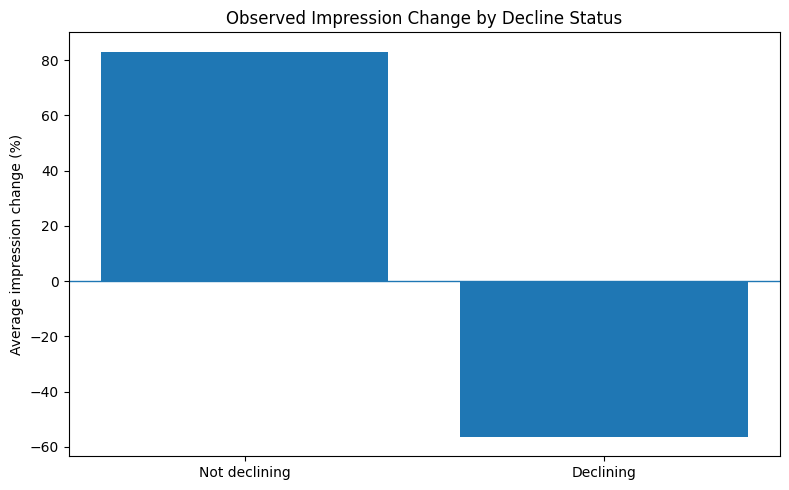

Figure exported to: work/figures/w07_decay_refresh_summary.png


In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    decay_summary['status'],
    decay_summary['avg_change_pct']
)

plt.axhline(0, linewidth=1)

plt.ylabel('Average impression change (%)')
plt.title('Observed Impression Change by Decline Status')

plt.tight_layout()

figure_path = "work/figures/w07_decay_refresh_summary.png"
plt.savefig(figure_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure exported to: {figure_path}")

In [36]:
required_columns = [
    'action_rank',
    'client_hash_id',
    'content_hash_id',
    'recommended_action',
    'reason_codes',
    'decline_probability',
    'impression_change_pct'
]

required_actions = {
    'REVIEW',
    'QUICK_WIN',
    'MONITOR',
    'NO_ACTION'
}

assert all(
    col in ranked_queue.columns
    for col in required_columns
), "Missing required queue columns"

assert set(ranked_queue['recommended_action'].unique()) <= required_actions, \
    "Unexpected action found"

assert len(ranked_queue) == len(model_data), \
    "Queue size does not match model data"

assert ranked_queue['action_rank'].is_unique, \
    "Action ranks are not unique"

assert os.path.exists("work/outputs/w07_ranked_action_queue.csv"), \
    "Queue CSV was not exported"

assert os.path.exists("work/figures/w07_decay_refresh_summary.png"), \
    "Decay figure was not exported"

print("W07 SELF-CHECK: PASSED")
print(f"Queue rows: {len(ranked_queue)}")
print("Actions:")
print(ranked_queue['recommended_action'].value_counts())

W07 SELF-CHECK: PASSED
Queue rows: 102203
Actions:
recommended_action
REVIEW       66862
NO_ACTION    19602
QUICK_WIN     8928
MONITOR       6811
Name: count, dtype: int64
